In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from pathlib import Path

hr_folder = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/HR_data")

# Cargamos todos los ecsv
ecsv_files = sorted(hr_folder.glob("*.ecsv"))

print("Archivos encontrados:", len(ecsv_files))

tables = []

for file in ecsv_files:
    try:
        table = Table.read(file, format="ascii.ecsv")
        tables.append(table)
        print(f"Leído: {file.name} | filas: {len(table)}")
    except Exception as e:
        print(f"Error leyendo {file.name}: {e}")

# Unimos las tablas
gaia_hr_table = vstack(tables)

print("Total filas:", len(gaia_hr_table))
print("Columnas:", gaia_hr_table.colnames)

Archivos encontrados: 18899
Leído: chunk_00000.ecsv | filas: 12
Leído: chunk_00001.ecsv | filas: 15
Leído: chunk_00002.ecsv | filas: 11
Leído: chunk_00003.ecsv | filas: 7
Leído: chunk_00004.ecsv | filas: 13
Leído: chunk_00005.ecsv | filas: 8
Leído: chunk_00006.ecsv | filas: 8
Leído: chunk_00007.ecsv | filas: 13
Leído: chunk_00008.ecsv | filas: 2
Leído: chunk_00009.ecsv | filas: 6
Leído: chunk_00010.ecsv | filas: 11
Leído: chunk_00011.ecsv | filas: 2
Leído: chunk_00012.ecsv | filas: 3
Leído: chunk_00013.ecsv | filas: 7
Leído: chunk_00014.ecsv | filas: 5
Leído: chunk_00015.ecsv | filas: 5
Leído: chunk_00016.ecsv | filas: 6
Leído: chunk_00017.ecsv | filas: 7
Leído: chunk_00018.ecsv | filas: 5
Leído: chunk_00019.ecsv | filas: 7
Leído: chunk_00020.ecsv | filas: 9
Leído: chunk_00021.ecsv | filas: 4
Leído: chunk_00022.ecsv | filas: 9
Leído: chunk_00023.ecsv | filas: 6
Leído: chunk_00024.ecsv | filas: 3
Leído: chunk_00025.ecsv | filas: 2
Leído: chunk_00026.ecsv | filas: 4
Leído: chunk_00027.ec

In [ ]:
gaia_hr_df = gaia_hr_table.to_pandas()
gaia_hr_df_unique = gaia_hr_df.drop_duplicates(subset="source_id", keep="first")

print("Filas originales:", len(gaia_hr_df))
print("Filas tras eliminar duplicados:", len(gaia_hr_df_unique))
print("Source_id únicos:", gaia_hr_df_unique["source_id"].nunique())

Filas originales: 386923
Filas tras eliminar duplicados: 126617
Source_id únicos: 126617


In [1]:
import h5py

path = "/Users/carlasequero/Desktop/trabajo-fin-master/solution/dataset_extraction_pipeline/data/06_training_data/training_03.h5"

with h5py.File(path, "r") as f:
    print(list(f.keys()))

import numpy as np

with h5py.File(path, "r") as f:
    X = f["X"][:]
    gaia_ID = f["gaia_source_id"][:]

print(gaia_ID.shape)

['X', 'X_err', 'gaia_source_id', 'gaia_wavelength_nm', 'sdss_obj_id', 'sdss_wavelength_aa', 'y']
(55621,)


In [ ]:
from astropy.table import Table
import numpy as np
from pathlib import Path

# Cargamos la tabla de Gaia guardada en local
gaia_data_path = Path("../data/gaia_data.ecsv")

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

In [6]:
# Usamos solo los id comunes
gaia_data_df_no_dup = gaia_data_df[
    gaia_data_df["source_id"].isin(gaia_ID)
].copy()


In [7]:
print("Filas finales para HR:", len(gaia_data_df_no_dup))

Filas finales para HR: 55368


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


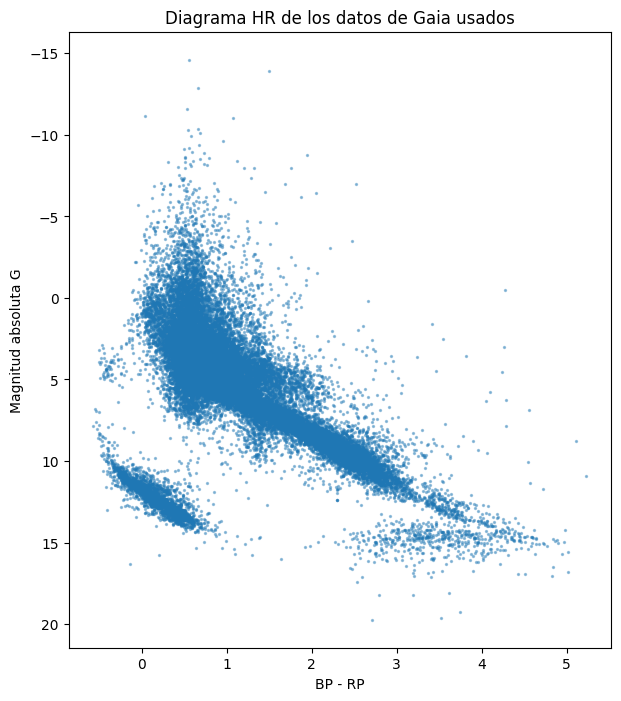

In [9]:
import matplotlib.pyplot as plt
bp_rp = gaia_data_df_no_dup["bp_rp"]
g_mag = gaia_data_df_no_dup["phot_g_mean_mag"]
parallax = gaia_data_df_no_dup["parallax"]

abs_g_mag = g_mag + 5 * np.log10(parallax) - 10

valid_hr = (
    np.isfinite(bp_rp)
    & np.isfinite(abs_g_mag)
    & np.isfinite(parallax)
    & (parallax > 0)
)

plt.figure(figsize=(7, 8))

plt.scatter(
    bp_rp[valid_hr],
    abs_g_mag[valid_hr],
    s=2,
    alpha=0.4
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("Magnitud absoluta G")
plt.title("Diagrama HR de los datos de Gaia usados")
plt.show()

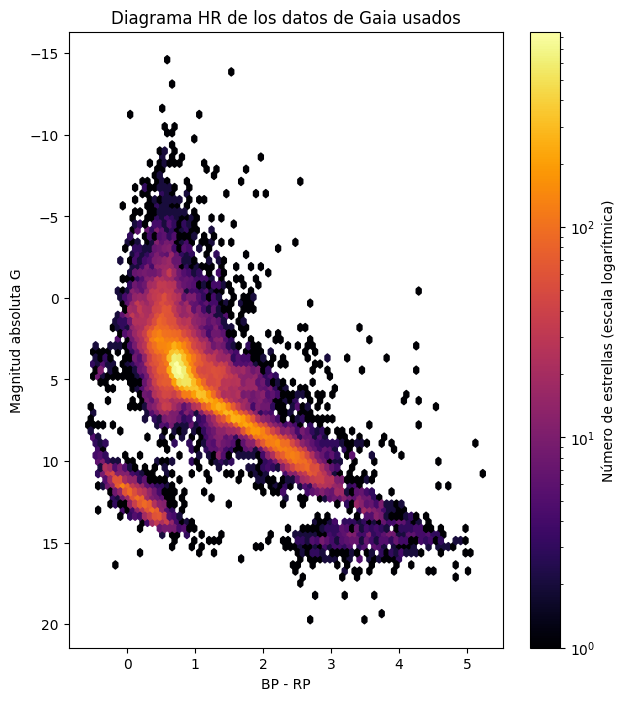

In [10]:
plt.figure(figsize=(7, 8))

plt.hexbin(
    bp_rp[valid_hr],
    abs_g_mag[valid_hr],
    gridsize=80,
    mincnt=1,
    bins="log",
    cmap="inferno"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("Magnitud absoluta G")
plt.title("Diagrama HR de los datos de Gaia usados")
plt.colorbar(label="Número de estrellas (escala logarítmica)")
plt.show()